# Stage 4 — Analysis & Visualization

**Goal:** Test whether female candidates cite proportionally more women than male candidates do, and visualize the gendered citation networks.

By the end of this notebook you will have:
- The core statistical result: do female candidates cite more women?
- Visualizations of citation patterns by gender
- Temporal evolution of gendered citations across election years

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from scipy import stats

PROJECT_ROOT = Path("..")
GENDER_COLORS = {"homme": "steelblue", "femme": "coral"}

df = pd.read_csv(PROJECT_ROOT / "data" / "citations_with_gender.csv", low_memory=False)
print(f"Citations loaded: {len(df):,}")
print(f"\nCandidate gender distribution:")
print(df.drop_duplicates("candidate_id")["candidate_sex"].value_counts())
print(f"\nCited-person gender distribution:")
print(df["cited_gender"].value_counts())

Citations loaded: 50,416

Candidate gender distribution:
candidate_sex
homme    14725
femme     1616
Name: count, dtype: int64

Cited-person gender distribution:
cited_gender
male                  30995
unknown               17073
female                 2337
non-binary                7
transgender female        4
Name: count, dtype: int64


In [2]:
queer = df[df["cited_gender"].isin(["transgender female", "non-binary"])]                                                                                   
print(queer[["cited_person_clean", "wikidata_label", "candidate_sex"]].drop_duplicates("cited_person_clean").to_string()) 

     cited_person_clean  wikidata_label candidate_sex
4416         Remy Huber  Rémy Huberdeau         homme
8648              De We  Anuna De Wever         femme


## 1. Core Question: Do female candidates cite more women?

For each candidate, we compute the share of their citations that go to female figures (among citations with known gender). We then compare this share between female and male candidates using a Mann-Whitney U test (non-parametric, robust to skewed distributions).

In [3]:
# Keep only citations with known gender
df_known = df[df["cited_gender"].isin(["male", "female"])].copy()

# Per candidate: share of citations going to female figures
per_candidate = (
    df_known.groupby(["candidate_id", "candidate_sex"])
    .apply(lambda g: (g["cited_gender"] == "female").mean())
    .reset_index(name="pct_female_cited")
)

female_scores = per_candidate[per_candidate["candidate_sex"] == "femme"]["pct_female_cited"]
male_scores   = per_candidate[per_candidate["candidate_sex"] == "homme"]["pct_female_cited"]

print(f"Female candidates with known citations: {len(female_scores)}")
print(f"Male candidates with known citations:   {len(male_scores)}")
print(f"\nMean % female cited — female candidates: {female_scores.mean()*100:.2f}%")
print(f"Mean % female cited — male candidates:   {male_scores.mean()*100:.2f}%")

stat, p = stats.mannwhitneyu(female_scores, male_scores, alternative="greater")
print(f"\nMann-Whitney U test (female > male):")
print(f"  U = {stat:.0f}, p = {p:.4f}")
print(f"  {'Significant at p<0.05' if p < 0.05 else 'Not significant'}")

Female candidates with known citations: 1320
Male candidates with known citations:   12262

Mean % female cited — female candidates: 43.99%
Mean % female cited — male candidates:   4.69%

Mann-Whitney U test (female > male):
  U = 12463618, p = 0.0000
  Significant at p<0.05


## 2. Visualization — Distribution of female citation share by candidate gender

## 2b. Top cited female figures — normalized by group size

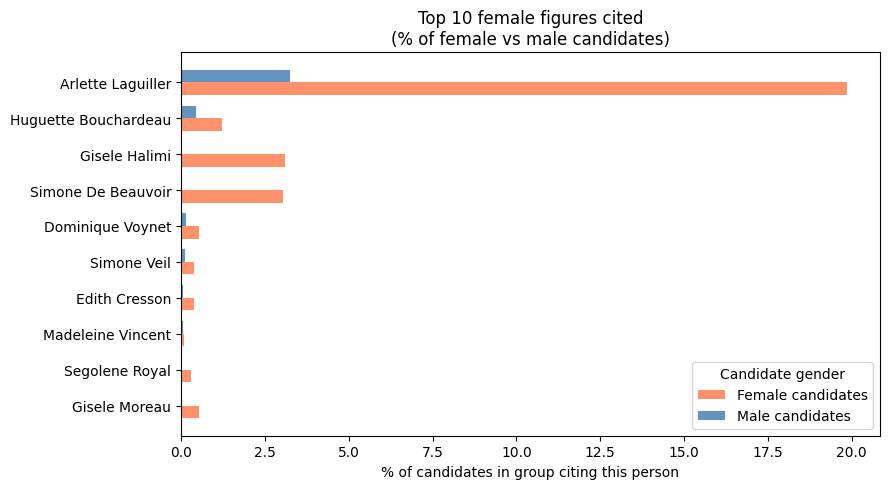

In [8]:
total_female_cands = df_known[df_known["candidate_sex"] == "femme"]["candidate_id"].nunique()
total_male_cands   = df_known[df_known["candidate_sex"] == "homme"]["candidate_id"].nunique()

top_pct = (
    df_known[df_known["cited_gender"] == "female"]
    .groupby(["cited_person_clean", "candidate_sex"])["candidate_id"]
    .nunique()
    .unstack(fill_value=0)
    .assign(total=lambda x: x.sum(axis=1))
    .sort_values("total", ascending=False)
    .head(10)
    .drop(columns="total")
)
top_pct["femme_pct"] = top_pct.get("femme", 0) / total_female_cands * 100
top_pct["homme_pct"] = top_pct.get("homme", 0) / total_male_cands * 100

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(top_pct))
width = 0.35
ax.barh([i + width/2 for i in x], top_pct["femme_pct"], width,
        color="coral", alpha=0.85, label="Female candidates")
ax.barh([i - width/2 for i in x], top_pct["homme_pct"], width,
        color="steelblue", alpha=0.85, label="Male candidates")
ax.set_yticks(list(x))
ax.set_yticklabels(top_pct.index)
ax.invert_yaxis()
ax.set_xlabel("% of candidates in group citing this person")
ax.set_title("Top 10 female figures cited\n(% of female vs male candidates)")
ax.legend(title="Candidate gender")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "fig_top_female_pct.png", dpi=150)
plt.show()

## 2c. What do female candidates cite beyond women?

Top cited figures by female vs male candidates (all genders), normalized by group size. We then identify figures that appear in female top 20 but not male top 20 — the distinctive references of female candidates.

In [9]:
df_all = df.copy()  # use full dataset, not just known-gender citations
total_f = df_all[df_all["candidate_sex"] == "femme"]["candidate_id"].nunique()
total_m = df_all[df_all["candidate_sex"] == "homme"]["candidate_id"].nunique()

def top_cited_pct(sex, n=20):
    return (
        df_all[df_all["candidate_sex"] == sex]
        .groupby("cited_person_clean")["candidate_id"]
        .nunique()
        .div(total_f if sex == "femme" else total_m)
        .mul(100)
        .sort_values(ascending=False)
        .head(n)
    )

female_top = top_cited_pct("femme", 20)
male_top   = top_cited_pct("homme", 20)

# Figures distinctive to female candidates
female_only = set(female_top.index) - set(male_top.index)
male_only   = set(male_top.index) - set(female_top.index)

print("=== Top 20 cited by FEMALE candidates (% of female manifestos) ===")
print(female_top.round(2).to_string())

print("\n=== Top 20 cited by MALE candidates (% of male manifestos) ===")
print(male_top.round(2).to_string())

print("\n=== In female top 20 but NOT male top 20 ===")
for name in female_top.index:
    if name in female_only:
        print(f"  {name:40s} {female_top[name]:.2f}% female")

print("\n=== In male top 20 but NOT female top 20 ===")
for name in male_top.index:
    if name in male_only:
        print(f"  {name:40s} {male_top[name]:.2f}% male")

=== Top 20 cited by FEMALE candidates (% of female manifestos) ===
cited_person_clean
Francois Mitterrand         20.54
Arlette Laguiller           16.21
Michel Rocard                5.01
Le Pen                       4.33
De Wendel                    4.27
Jean-Marie Le Pen            4.21
Brice Lalonde                4.15
Gisele Halimi                2.54
Jacques Monod                2.48
Jean Rostand                 2.48
Simone De Beauvoir           2.48
Jacques Chirac               1.73
Giscard D'Estaing            1.67
F. Mitterrand                1.18
Andre Lajoinie               1.05
Valery Giscard D'Estaing     1.05
Georges Pompidou             1.05
President Pompidou           0.99
R. Barre                     0.99
Huguette Bouchardeau         0.99

=== Top 20 cited by MALE candidates (% of male manifestos) ===
cited_person_clean
Francois Mitterrand               15.67
Michel Rocard                      4.31
Le Pen                             3.03
Jean-Marie Le Pen              

/var/folders/l4/9495mdtj3mvf9dpmqvxz440c0000gn/T/ipykernel_66935/3248664425.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_plot, labels=["Female candidates", "Male candidates"],


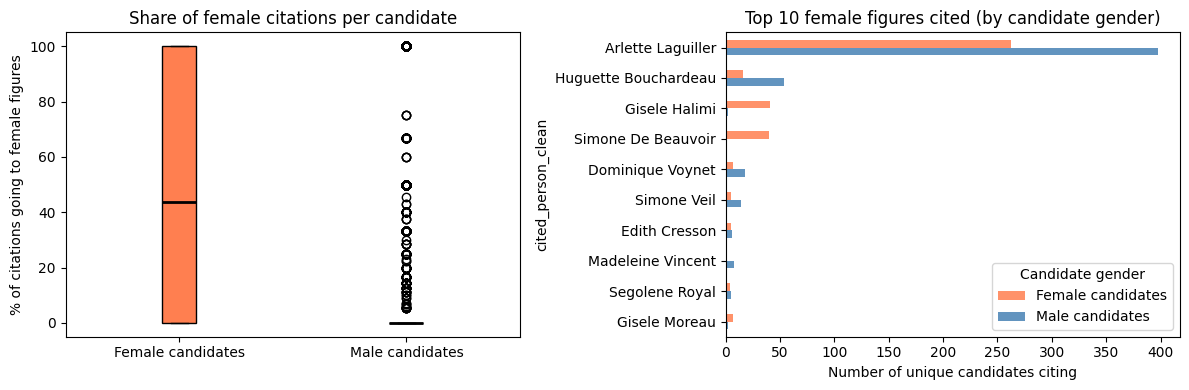

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: boxplot ---
data_plot = [female_scores * 100, male_scores * 100]
bp = axes[0].boxplot(data_plot, labels=["Female candidates", "Male candidates"],
                     patch_artist=True, medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor("coral")
bp["boxes"][1].set_facecolor("steelblue")
axes[0].set_ylabel("% of citations going to female figures")
axes[0].set_title("Share of female citations per candidate")

# --- Right: top cited female figures by candidate gender ---
top_female_figures = (
    df_known[df_known["cited_gender"] == "female"]
    .groupby(["cited_person_clean", "candidate_sex"])["candidate_id"]
    .nunique()
    .unstack(fill_value=0)
    .assign(total=lambda x: x.sum(axis=1))
    .sort_values("total", ascending=False)
    .head(10)
    .drop(columns="total")
)

top_female_figures.plot(
    kind="barh", ax=axes[1],
    color=[GENDER_COLORS.get(c, "gray") for c in top_female_figures.columns],
    alpha=0.85
)
axes[1].set_title("Top 10 female figures cited (by candidate gender)")
axes[1].set_xlabel("Number of unique candidates citing")
axes[1].invert_yaxis()
axes[1].legend(["Female candidates", "Male candidates"], title="Candidate gender")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "fig_gender_citations.png", dpi=150)
plt.show()

## 3. Temporal evolution — female citation share by year

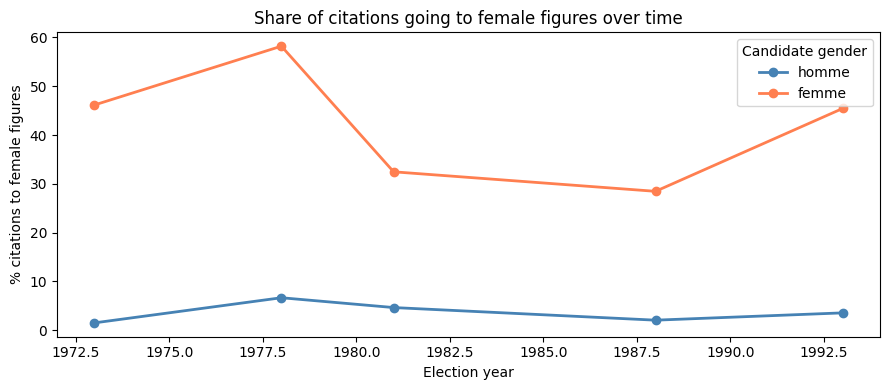

 year candidate_sex  pct_female_cited
 1973         femme         46.153846
 1973         homme          1.476840
 1978         femme         58.220025
 1978         homme          6.633528
 1981         femme         32.457496
 1981         homme          4.620668
 1988         femme         28.454172
 1988         homme          2.033347
 1993         femme         45.438596
 1993         homme          3.529783


In [11]:
year_col = "year" if "year" in df_known.columns else "year_x"

temporal = (
    df_known.groupby([year_col, "candidate_sex"])
    .apply(lambda g: (g["cited_gender"] == "female").mean() * 100)
    .reset_index(name="pct_female_cited")
)

fig, ax = plt.subplots(figsize=(9, 4))
for sex, color in GENDER_COLORS.items():
    subset = temporal[temporal["candidate_sex"] == sex]
    ax.plot(subset[year_col], subset["pct_female_cited"],
            marker="o", color=color, linewidth=2, label=sex)

ax.set_title("Share of citations going to female figures over time")
ax.set_xlabel("Election year")
ax.set_ylabel("% citations to female figures")
ax.legend(title="Candidate gender")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "fig_temporal.png", dpi=150)
plt.show()

print(temporal.to_string(index=False))

## 4. Summary

- `fig_gender_citations.png` — boxplot + top female figures by candidate gender
- `fig_temporal.png` — temporal evolution of female citation share

**Next:** `05_paper.ipynb` or write the paper using these results.